In [4]:
#############################################
#     Yolo como detector con CIFAR-10       #
#############################################

#1. Instalamos los paquetes de ultralytics necesarios y el dataset de tensorflow
!pip install ultralytics tensorflow tensorflow-datasets
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.7 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Cargar modelo pre-entrenado que sabe detectar objetos genéricos
model = YOLO("yolov8n.pt")  # puedes usar yolov8s.pt si tu GPU lo aguanta


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
# Función de proceso de imagenes , se obtiene la predicción(inferencia) en YOLO
# y pinto las cajas (bounding boxes)con la clase y la confianza
def mostrar_predicciones(imagen_ruta, conf=0.5):
    # Leer imagen
    img = cv2.imread(imagen_ruta)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Inferencia
    results = model(img_rgb, conf=conf)

    # results[0] contiene las predicciones de la imagen
    res = results[0]

    # Dibujar bounding boxes
    for box in res.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls = int(box.cls[0].item())
        score = float(box.conf[0].item())
        label = model.names[cls]

        # Dibujar rectángulo
        cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)
        text = f"{label} {score:.2f}"
        cv2.putText(img_rgb, text, (int(x1), int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

    return res


0: 448x640 1 person, 1 car, 1 bus, 2 trucks, 165.2ms
Speed: 4.9ms preprocess, 165.2ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


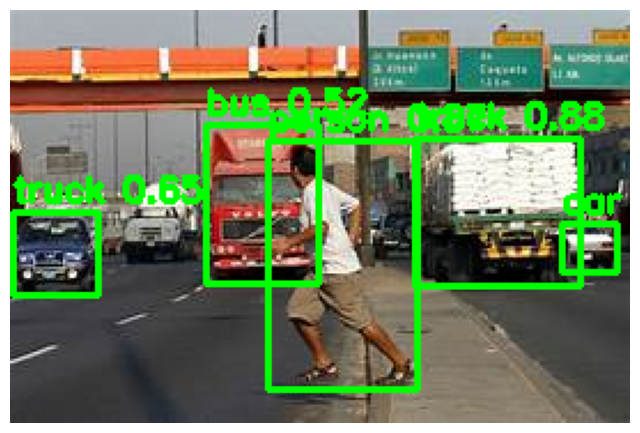

Clase: truck, Confianza: 0.88, BBox: (176.7, 56.0, 248.6, 120.9)
Clase: person, Confianza: 0.87, BBox: (112.9, 58.0, 177.4, 165.4)
Clase: truck, Confianza: 0.65, BBox: (1.1, 88.3, 38.9, 124.1)
Clase: car, Confianza: 0.56, BBox: (240.6, 93.1, 264.1, 114.1)
Clase: bus, Confianza: 0.52, BBox: (85.6, 50.5, 134.3, 119.3)


In [20]:
# Demo
#Probamos el modelo con una imagen
#resultado = mostrar_predicciones("/content/drive/MyDrive/coche1.jpg", conf=0.5) #No lo detecta
#resultado = mostrar_predicciones("/content/drive/MyDrive/niño.jpg", conf=0.5) #No lo detecta es un dibujo
#resultado = mostrar_predicciones("/content/drive/MyDrive/niños.jpg", conf=0.5) #Si lo detecta imagen real
#resultado = mostrar_predicciones("/content/drive/MyDrive/coche2.jpg", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/semaforo.jpg", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/pajaro.jpg", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/CIFAR-10/train/ship/train_21862.png", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/CIFAR-10/train/automobile/train_27871.png", conf=0.5)
resultado = mostrar_predicciones("/content/drive/MyDrive/peaton.jpg", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/cochesPeatones.jpg", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/cadena3.jpg", conf=0.5)
#resultado = mostrar_predicciones("/content/drive/MyDrive/cadena2.jpg", conf=0.4)





# Ver clases, scores y coordenadas en bruto
for box in resultado.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls = int(box.cls[0].item())
    score = float(box.conf[0].item())
    label = model.names[cls]
    print(f"Clase: {label}, Confianza: {score:.2f}, BBox: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

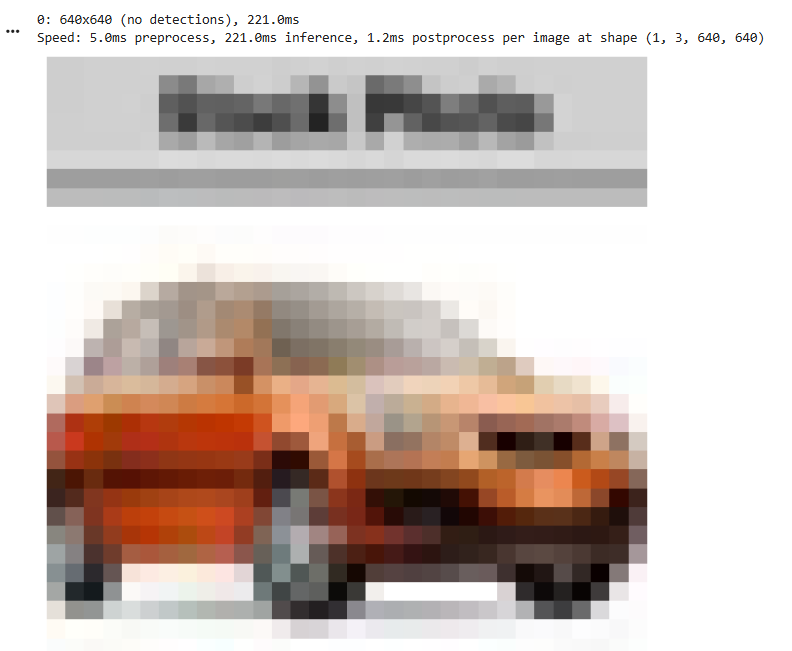

**YOLO falla porque :**
- CIFAR-10 no tiene resolución suficiente
- CIFAR-10 no tiene bounding boxes
- Las clases no coinciden con COCO (dataset de YOLO)
- YOLO fue entrenado para escenas reales, no mini-imágenes
- El dominio es completamente distinto.

**Comparamos CNN vs YOLO**
- CNN clasifica pero no localiza
- YOLO localiza pero necesita datos adecuados
- YOLO es superior para detección real
- Pero en CIFAR-10 no funciona porque el dataset no es adecuado

**Conclusión comparativa**
La CNN funciona porque CIFAR-10 es un problema de clasificación.
YOLO falla porque CIFAR-10 no es un problema de detección.
El fallo no es del modelo, sino del desajuste entre la tarea y los datos.

# ¿Por qué YOLO es superiror a la CNN para la tarea de detección?

YOLO (You Only Look Once) pertenece a la familia de **modelos de detección** de objetos en **tiempo real**, y está optimizado para responder simultáneamente a dos preguntas:
- ¿Qué objetos hay en la imagen?
- ¿Dónde se encuentran exactamente?

**1. YOLO realiza detección y clasificación en una sola pasada (One-Stage Detector)**
YOLO procesa la imagen completa en un único paso a través de la red, generando directamente:
- las clases detectadas,
- las coordenadas de las bounding boxes,
- y los niveles de confianza.
Este enfoque “de una sola pasada” es extremadamente eficiente y permite alcanzar velocidades de inferencia muy superiores a las de los detectores tradicionales basados en dos etapas (como R-CNN o Faster R-CNN).
En contraste, la CNN de la Entrega 1 solo produce una etiqueta global, sin capacidad para localizar objetos ni para procesar múltiples regiones de interés.

**2. YOLO incorpora un mecanismo explícito de localización espacia**
Mientras que la CNN aprende representaciones globales para clasificar la imagen completa, YOLO divide la imagen en una cuadrícula y predice:
- posiciones (x, y),
- anchura y altura de los objetos,
- y la probabilidad de que exista un objeto en cada celda.
Este mecanismo convierte a YOLO en un modelo capaz de entender la estructura espacial de la escena, algo que una CNN de clasificación no puede hacer por diseño.

**3. YOLO es má eficiente computacionalmente para detección**
Durante la practicas realizadas se ha posido confirmar este punto, la arquitectura compacta y el diseño de una sola pasada logra un alto rendimiento de GPU y CPU, procesamiento en tiempo real y menor coste computacional que otros detectores.
La CNN, aunque ligera, no está diseñada para detección y requeriría mecanismos adicionales que la harían mucho más lenta e ineficiente.












